<a href="https://colab.research.google.com/github/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/main/Notebook/02_Cria%C3%A7%C3%A3o_Target.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Criação de Target - Bom e Mau pagador**

In [23]:
from google.colab import drive
import pandas as pd
import numpy as np
from pathlib import Path
import os

# 1. Tentar conectar ao Google Drive
try:
    drive.mount('/content/drive')
except Exception as e:
    print("Aviso: Não foi possível montar o Google Drive automaticamente. Prosseguindo...")

# Caminho do Google Drive definido no Notebook 01
PROCESSED_DIR = Path('/content/drive/MyDrive/Tech_Challenge_Fase_2/data/processed')
INPUT_PATH_CADASTRO = PROCESSED_DIR / 'application_record_tratado.parquet'
INPUT_PATH_CREDITO = PROCESSED_DIR / 'credit_record_tratado.parquet'

# 2. Carregar as bases
path_cad = Path('/content/application_record.csv')
path_cred = Path('/content/credit_record.csv')

if path_cad.exists() and path_cred.exists():
    print("✅ CSVs locais detectados na raiz '/content/'. Carregando e tratando os dados...")
    df_cadastro = pd.read_csv(path_cad)
    df_credito = pd.read_csv(path_cred)

    # Aplicar tratamentos equivalentes
    df_cadastro['Idade'] = (-df_cadastro['DAYS_BIRTH'] / 365.25).astype(int)
    df_cadastro['Anos_Trabalhados'] = df_cadastro['DAYS_EMPLOYED'].apply(lambda x: 0 if x > 0 else -x / 365.25)
    df_cadastro['CNT_FAM_MEMBERS_TRATADO'] = df_cadastro['CNT_FAM_MEMBERS'].clip(upper=5)

    # Como os parquets não estavam no Drive, vamos criá-los agora para sincronizar o Drive de forma definitiva!
    try:
        PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
        df_cadastro.to_parquet(INPUT_PATH_CADASTRO, index=False)
        df_credito.to_parquet(INPUT_PATH_CREDITO, index=False)
        print(f"✅ Excelente! Arquivos salvos e sincronizados com sucesso no seu Drive em:\n -> {PROCESSED_DIR}")
    except Exception as e:
        print(f"⚠️ Aviso: Não foi possível salvar os parquets de volta no Drive ({e}). Mas a execução continuará normalmente usando as bases locais.")

elif INPUT_PATH_CADASTRO.exists() and INPUT_PATH_CREDITO.exists():
    df_cadastro = pd.read_parquet(INPUT_PATH_CADASTRO)
    df_credito = pd.read_parquet(INPUT_PATH_CREDITO)
    print("✅ Bases carregadas diretamente do Google Drive (Parquet) com sucesso!")
else:
    raise FileNotFoundError(
        "\n❌ ERRO: Não foi possível encontrar as bases em nenhuma das origens!\n"
        "Por favor, certifique-se de fazer o upload dos arquivos 'application_record.csv' e 'credit_record.csv' para a raiz do Colab (pasta '/content/')."
    )

# Definir variáveis globais necessárias para as células seguintes do Notebook 02
df_excel = df_cadastro.copy()  # Usado na célula 4eab1adf
target = 'MAU_PAGADOR'          # Usado na célula 4a7c9754

print(f"\nShape df_cadastro (df_excel): {df_cadastro.shape}")
print(f"Shape df_credito: {df_credito.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ CSVs locais detectados na raiz '/content/'. Carregando e tratando os dados...
✅ Excelente! Arquivos salvos e sincronizados com sucesso no seu Drive em:
 -> /content/drive/MyDrive/Tech_Challenge_Fase_2/data/processed

Shape df_cadastro (df_excel): (438557, 21)
Shape df_credito: (1048575, 3)


 ## **Definição de"Mau pagador" e "Bom pagador"**

Criamos um DataFrame por "ID"` contendo a classificação de risco (Target) para cada cliente, onde definimos dois critérios:

**Permissivo**
Este critério classifica como mau pagador qualquer cliente que tenha registrado, em pelo menos um mês, um status (1, 2, 3, 4 ou 5). Aqui é mais conservador, para que qualquer sinal de atraso, mesmo que pequeno, é tratado como evidência suficiente de comportamento de pagamento problemático, já que atrasos leves recorrentes tendem a preceder atrasos mais graves.

**Mau pagador**
São os clientes com atraso superior a 60 dias (Status 2, 3, 4 ou 5) no histórico, e o restante como Bom Pagador (0).

Pela classificação, dos 45985 clientes (ID únicos), 45318 são bons pagadores e 667 maus pagadores.

In [40]:
# 1. Critério Padrão (Atraso > 60 dias): Status 2, 3, 4, 5
df_credito['MAU_PAGADOR'] = df_credito['STATUS'].isin(['2', '3', '4', '5']).astype(int)

# 2. Critério Permissivo (Atraso >= 30 dias): Status 1, 2, 3, 4, 5
df_credito['PERMISSIVO'] = df_credito['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

# Agrupando por ID para pegar o pior status histórico de cada cliente sob cada critério
df_target_padrao = df_credito.groupby('ID')['MAU_PAGADOR'].max().reset_index()
df_target_permissivo = df_credito.groupby('ID')['PERMISSIVO'].max().reset_index()

# Unificando os targets em um único dataframe de referência
df_target = pd.merge(df_target_padrao, df_target_permissivo, on='ID', how='inner')

In [41]:
print("=== PROPORÇÃO DE CLIENTES - CRITÉRIO MAU PAGADOR (> 60 dias) ===")
display(df_target['MAU_PAGADOR'].value_counts())
display(df_target['MAU_PAGADOR'].value_counts(normalize=True) * 100)

print("\n=== PROPORÇÃO DE CLIENTES - CRITÉRIO PERMISSIVO (>= 30 dias) ===")
display(df_target['PERMISSIVO'].value_counts())
display(df_target['PERMISSIVO'].value_counts(normalize=True) * 100)

=== PROPORÇÃO DE CLIENTES - CRITÉRIO MAU PAGADOR (> 60 dias) ===


,count
MAU_PAGADOR,
0,45318
1,667


,proportion
MAU_PAGADOR,
0,98.549527
1,1.450473



=== PROPORÇÃO DE CLIENTES - CRITÉRIO PERMISSIVO (>= 30 dias) ===


,count
PERMISSIVO,
0,40635
1,5350


,proportion
PERMISSIVO,
0,88.365771
1,11.634229


**Avaliação**

Quando mudamos a régua de corte de 30 dias para 60 dias, o volume de "Maus Pagadores" salta de 5350 para 667 (8 vezes menor). Ou seja, dos 5.350 clientes que atrasaram pelo menos uma vez mais de 30 dias (Permissivo), apenas 667 deixaram essa dívida passar de 60 dias (Maus pagadores).

## **Unificação das bases de dados**

Para definir as variáveis target corretamente e possibilitar a análise de perfil, cruzamos os dados cadastrais da base de propostas (df_excel) com as classificações de risco geradas (df_target) através do identificador único (ID).

Após essa unificação, a base final consolidada passou a apresentar 616 clientes maus pagadores (no critério de atraso > 60 dias) e 4.291 clientes sob o critério permissivo (atraso >= 30 dias).

Essa redução nos valores absolutos ocorre porque:
* No critério padrão, 51 dos 667 clientes originais possuíam histórico de pagamentos, mas não apresentavam ficha cadastral na base de propostas.
* No critério permissivo, 1.059 dos 5.350 clientes originais também não possuíam correspondência cadastral.

Como não é possível traçar perfis ou treinar modelos preditivos para clientes sem dados cadastrais, esses registros sem correspondência foram descartados de forma consistente durante a consolidação.

In [44]:
# Unificando a base cadastral (df_excel) com o dataframe contendo ambos os targets
df = pd.merge(df_excel, df_target, on='ID', how='inner')

# Agora o seu DataFrame 'df' possui de forma independente as duas variáveis:
# 1. df['MAU_PAGADOR'] -> Critério Padrão (> 60 dias)
# 2. df['PERMISSIVO']   -> Critério Permissivo (>= 30 dias)

print(f"✅ Base consolidada unificada com sucesso! Total de linhas: {df.shape[0]}")
print("\nDistribuição do Target Padrão (MAU_PAGADOR - > 60 dias):")
print(df['MAU_PAGADOR'].value_counts())
print(df['MAU_PAGADOR'].value_counts(normalize=True) * 100)

print("\nDistribuição do Target Permissivo (PERMISSIVO - >= 30 dias):")
print(df['PERMISSIVO'].value_counts())
print(df['PERMISSIVO'].value_counts(normalize=True) * 100)

✅ Base consolidada unificada com sucesso! Total de linhas: 36457

Distribuição do Target Padrão (MAU_PAGADOR - > 60 dias):
MAU_PAGADOR
0    35841
1      616
Name: count, dtype: int64
MAU_PAGADOR
0    98.310338
1     1.689662
Name: proportion, dtype: float64

Distribuição do Target Permissivo (PERMISSIVO - >= 30 dias):
PERMISSIVO
0    32166
1     4291
Name: count, dtype: int64
PERMISSIVO
0    88.22997
1    11.77003
Name: proportion, dtype: float64


## **Análise de Perfil: Permissivo vs Maus Pagadores**

Analisamos como a proporção de inadimplentes se comporta em cada categoria cadastral sob as duas réguas de risco:
1. Critério MAU_PAGADOR: Atraso > 60 dias.
2. Critério PERMISSIVO: Atraso >= 30 dias.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if 'FAIXA_RENDA' not in df.columns and 'AMT_INCOME_TOTAL' in df.columns:
    faixas = [0, 100000, 150000, 200000, 300000, np.inf]
    labels = ['Até 100k', '100k a 150k', '150k a 200k', '200k a 300k', 'Mais de 300k']
    df['FAIXA_RENDA'] = pd.cut(df['AMT_INCOME_TOTAL'], bins=faixas, labels=labels)

def analisar_taxas_por_categoria(df, coluna, nome_coluna):
    # Calcular taxas médias (que correspondem à proporção de 1s na coluna binária)
    analise = df.groupby(coluna, observed=False).agg(
        Total_Clientes=('ID', 'count'),
        Taxa_Mau_pagador_Pct=('MAU_PAGADOR', lambda x: x.mean() * 100),
        Taxa_Permissivo_Pct=('PERMISSIVO', lambda x: x.mean() * 100)
    ).reset_index()

    print(f"=== COMPARAÇÃO DE INADIMPLÊNCIA POR {nome_coluna.upper()} ===")
    display(analise.round(2))

    df_melted = analise.melt(id_vars=[coluna], value_vars=['Taxa_Mau_pagador_Pct', 'Taxa_Permissivo_Pct'],
                            var_name='Criterio', value_name='Taxa_Pct')

    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_melted, x=coluna, y='Taxa_Pct', hue='Criterio', palette='Set1')
    plt.title(f'Taxa de Inadimplência por {nome_coluna}: Mau Pagador vs. Permissivo')
    plt.ylabel('Taxa de Inadimplência (%)')
    plt.xlabel(nome_coluna)
    plt.xticks(rotation=15)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

**1. Qual a Comparação por Faixa de Renda dos clientes inadimplentes?

=== COMPARAÇÃO DE INADIMPLÊNCIA POR FAIXA DE RENDA ===


,FAIXA_RENDA,Total_Clientes,Taxa_Mau_pagador_Pct,Taxa_Permissivo_Pct
0,Até 100k,5086,1.73,11.23
1,100k a 150k,10236,1.69,11.46
2,150k a 200k,7661,1.58,10.59
3,200k a 300k,9645,1.78,12.98
4,Mais de 300k,3829,1.62,12.64


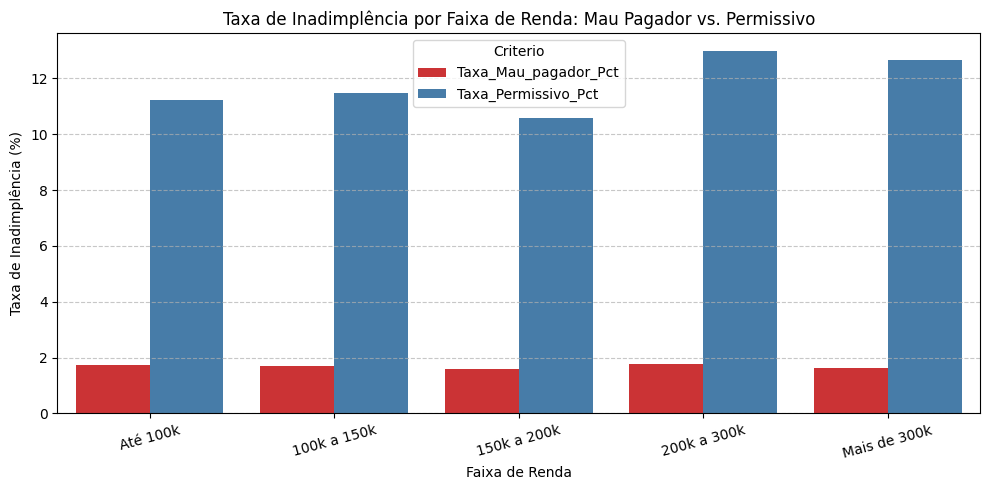

In [60]:
analisar_taxas_por_categoria(df, 'FAIXA_RENDA', 'Faixa de Renda')

**Avaliação**

**2. Qual o estado civil predominante entre os inadimplentes?**






=== COMPARAÇÃO DE INADIMPLÊNCIA POR ESTADO CIVIL ===


,NAME_FAMILY_STATUS,Total_Clientes,Taxa_Mau_pagador_Pct,Taxa_Permissivo_Pct
0,Civil marriage,2945,1.56,12.46
1,Married,25048,1.57,11.63
2,Separated,2103,1.47,10.70
3,Single / not married,4829,2.09,12.90
4,Widow,1532,2.94,10.57


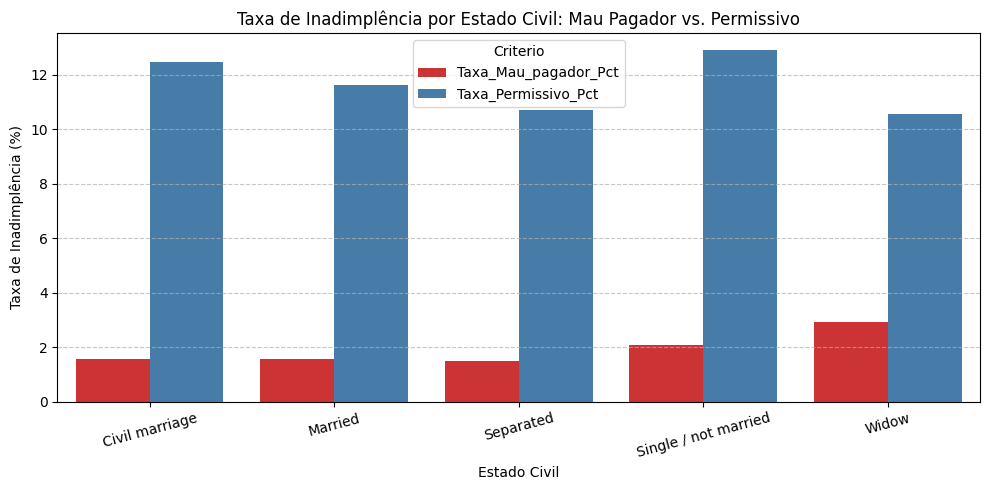

In [59]:
analisar_taxas_por_categoria(df, 'NAME_FAMILY_STATUS', 'Estado Civil')

**Avaliação**


**3. Qual o nível de escolaridade predominantes nos inadimplentes?**

=== DISTRIBUIÇÃO DO NÍVEL DE ESCOLARIDADE ===


,Bom Pagador (%),Mau Pagador (%)
NAME_EDUCATION_TYPE,,
Academic degree,0.09,NaN
Higher education,27.04,27.76
Incomplete higher,3.84,5.36
Lower secondary,1.02,1.62
Secondary / secondary special,68.01,65.26


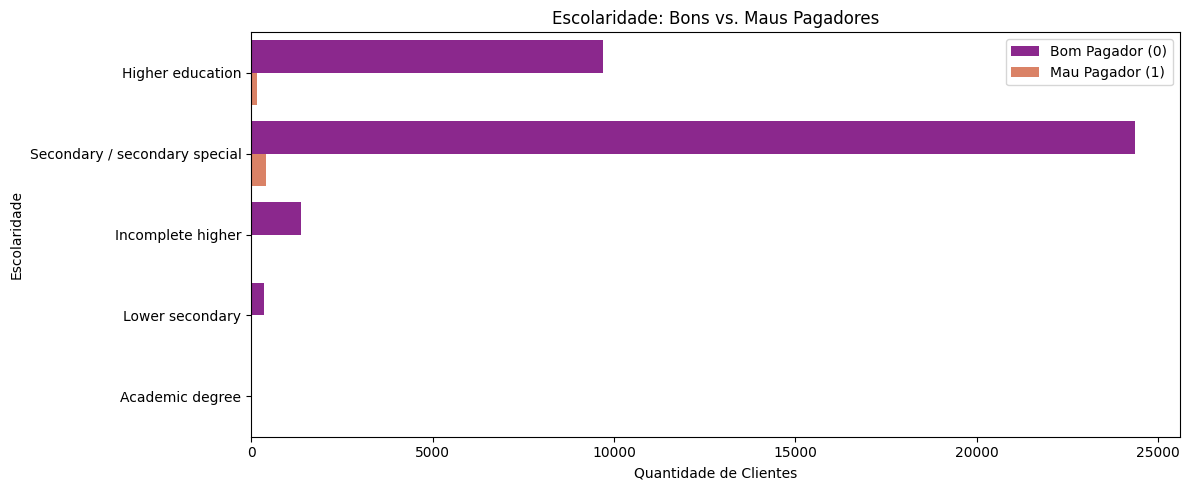

In [29]:
print("=== DISTRIBUIÇÃO DO NÍVEL DE ESCOLARIDADE ===")
escolaridade_perfil = df.groupby('MAU_PAGADOR')['NAME_EDUCATION_TYPE'].value_counts(normalize=True).unstack(level=0) * 100
escolaridade_perfil.columns = ['Bom Pagador (%)', 'Mau Pagador (%)']
display(escolaridade_perfil.round(2))

plt.figure(figsize=(12, 5))
sns.countplot(data=df, y='NAME_EDUCATION_TYPE', hue='MAU_PAGADOR', palette='plasma')
plt.title('Escolaridade: Bons vs. Maus Pagadores')
plt.ylabel('Escolaridade')
plt.xlabel('Quantidade de Clientes')
plt.legend(['Bom Pagador (0)', 'Mau Pagador (1)'])
plt.tight_layout()
plt.show()

**Avaliação**

O nível de escolaridade predominante em ambos os grupos é o secundário, representando cerca de 68% dos bons pagadores e 60% dos maus pagadores.

 Há um leve aumento na proporção de pessoas com  Higher education ou Incomplete Higher entre os maus pagadores (30% vs 27% dos maus pagadores e 6,6% vs. 3.8% nos bons pagadores, respectivamente).

**4. A ocupação interfere na inadimplência?**

=== TOP 10 OCUPAÇÕES MAIS FREQUENTES ===


,Bom Pagador (%),Mau Pagador (%)
OCCUPATION_TYPE,,
Laborers,24.73,23.46
Core staff,14.23,17.54
Drivers,8.45,11.61
Managers,12.00,11.14
Sales staff,13.92,10.66
High skill tech staff,5.48,7.11
Accountants,4.93,5.45
Security staff,2.34,3.08
Medicine staff,4.84,2.37


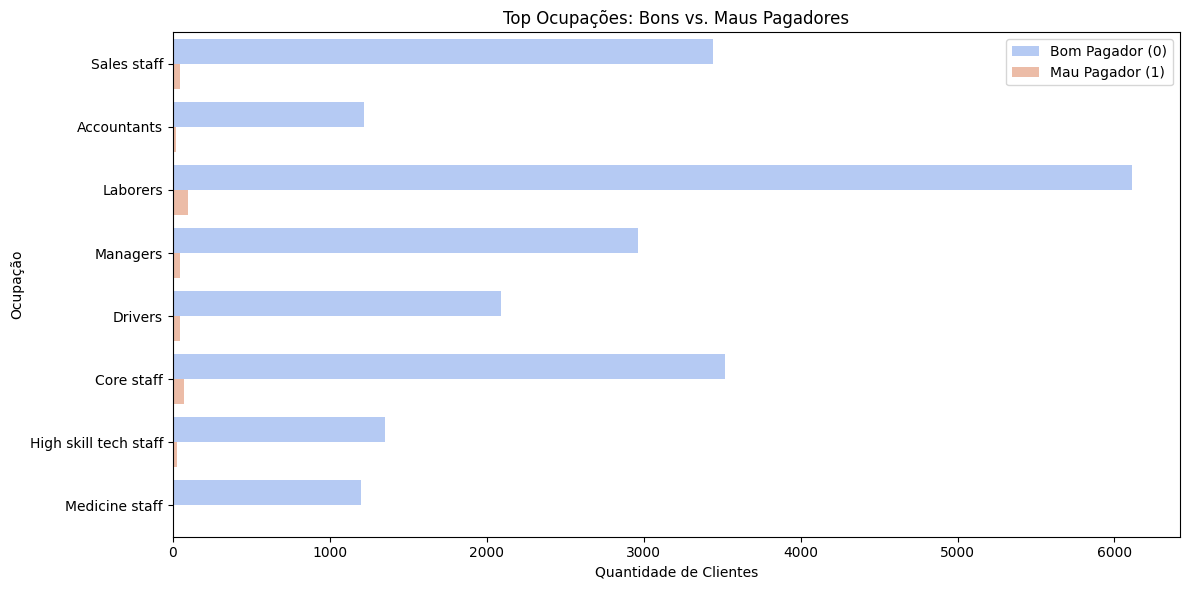

In [31]:
print("=== TOP 10 OCUPAÇÕES MAIS FREQUENTES ===")
ocupacao_perfil = df.groupby('MAU_PAGADOR')['OCCUPATION_TYPE'].value_counts(normalize=True).unstack(level=0) * 100
ocupacao_perfil.columns = ['Bom Pagador (%)', 'Mau Pagador (%)']
display(ocupacao_perfil.sort_values(by='Mau Pagador (%)', ascending=False).head(10).round(2))

plt.figure(figsize=(12, 6))
top_ocupacoes = df['OCCUPATION_TYPE'].value_counts().head(8).index
df_top_ocup = df[df['OCCUPATION_TYPE'].isin(top_ocupacoes)]
sns.countplot(data=df_top_ocup, y='OCCUPATION_TYPE', hue='MAU_PAGADOR', palette='coolwarm')
plt.title('Top Ocupações: Bons vs. Maus Pagadores')
plt.ylabel('Ocupação')
plt.xlabel('Quantidade de Clientes')
plt.legend(['Bom Pagador (0)', 'Mau Pagador (1)'])
plt.tight_layout()
plt.show()

**Avaliação**

- **Ocupações Desconhecidas:** Em ambos os grupos (bons e maus pagadores), mais de **31%** das ocupações não estão preenchidas ou constam como *Unknown*.
- **Principais Perfis nos Maus Pagadores:** Excluindo as categorias desconhecidas, a ocupação mais expressiva entre os inadimplentes é a de **Laborers** (trabalhadores braçais/operários), seguida por **Core staff** (equipe técnica/administrativa de apoio) e **Sales staff** (equipe de vendas).
- **Fator de Atenção:** A categoria **Security staff** (equipe de segurança) apresenta uma proporção significativamente maior entre os maus pagadores (**4.43%**) do que entre os bons pagadores (**2.34%**).

**5. A quantidade de membros da família influencia no aumento da inadimplência?



=== ESTATÍSTICA DESCRITIVA DA QTD DE MEMBROS DA FAMÍLIA ===
               count  mean   std  min  25%  50%  75%   max
MAU_PAGADOR                                               
0            35841.0  2.20  0.91  1.0  2.0  2.0  3.0  20.0
1              616.0  2.16  0.93  1.0  2.0  2.0  3.0   6.0

=== PROPORÇÃO DE TAMANHO DE FAMÍLIA (TRATADA) ===


,Bom Pagador (%),Mau Pagador (%)
CNT_FAM_MEMBERS_TRATADO,,
1.0,19.11,22.56
2.0,53.43,50.81
3.0,17.62,17.05
4.0,8.54,7.47
5.0,1.30,2.11


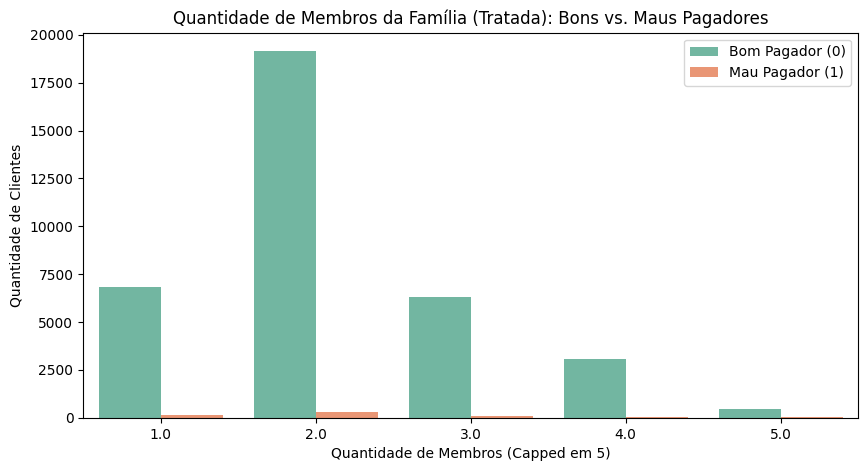

In [32]:
print("=== ESTATÍSTICA DESCRITIVA DA QTD DE MEMBROS DA FAMÍLIA ===")
print(df.groupby('MAU_PAGADOR')['CNT_FAM_MEMBERS'].describe().round(2))

print("\n=== PROPORÇÃO DE TAMANHO DE FAMÍLIA (TRATADA) ===")
familia_perfil = df.groupby('MAU_PAGADOR')['CNT_FAM_MEMBERS_TRATADO'].value_counts(normalize=True).unstack(level=0) * 100
familia_perfil.columns = ['Bom Pagador (%)', 'Mau Pagador (%)']
display(familia_perfil.round(2))

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='CNT_FAM_MEMBERS_TRATADO', hue='MAU_PAGADOR', palette='Set2')
plt.title('Quantidade de Membros da Família (Tratada): Bons vs. Maus Pagadores')
plt.xlabel('Quantidade de Membros (Capped em 5)')
plt.ylabel('Quantidade de Clientes')
plt.legend(['Bom Pagador (0)', 'Mau Pagador (1)'])
plt.show()

**Avaliação**

- **Semelhança entre Grupos:** A distribuição e o tamanho das famílias são extremamente semelhantes em ambos os perfis, indicando que o tamanho do núcleo familiar isoladamente não é um forte indicador de risco de crédito.
- **Famílias de 2 Pessoas:** São amplamente predominantes na base de dados, representando **53.4%** dos bons pagadores e **52.0%** dos maus pagadores.
- **Famílias Unitárias (1 Pessoa):** Há uma proporção ligeiramente maior de pessoas morando sozinhas entre os maus pagadores (**24.17%**) em comparação aos bons pagadores (**19.12%**).
- **Média Geral:** O tamanho médio das famílias é virtualmente idêntico (cerca de **2.19** para bons pagadores e **2.14** para maus pagadores).

## **Análise Combinada (Cruzamento de Variáveis)**

Realizamos cruzamentos entre as variáveis para tentar identificar padrões mais complexos de comportamento entre bons e maus pagadores.

**1. Idade vs. Anos Trabalhados por Perfil de Risco**

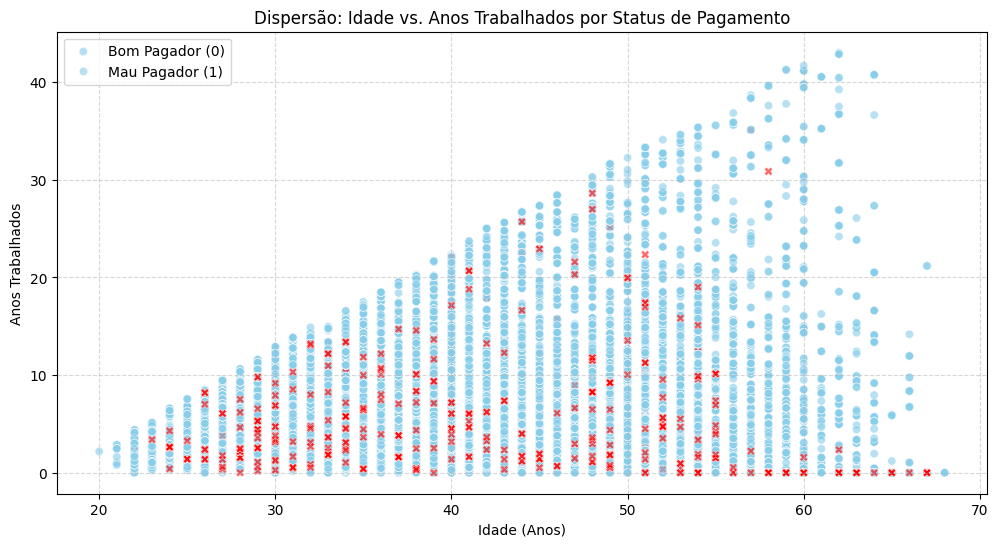

In [33]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='Idade',
    y='Anos_Trabalhados',
    hue='MAU_PAGADOR',
    palette={0: 'skyblue', 1: 'red'},
    alpha=0.6,
    style='MAU_PAGADOR'
)
plt.title('Dispersão: Idade vs. Anos Trabalhados por Status de Pagamento')
plt.xlabel('Idade (Anos)')
plt.ylabel('Anos Trabalhados')
plt.legend(['Bom Pagador (0)', 'Mau Pagador (1)'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Avaliação**

Ao analisarmos a relação entre a "Idade" dos clientes e o tempo em "Anos Trabalhados, destacando os perfis de risco (Maus Pagadores em Vermelho), observamos alguns padrões relevantes:

1. Concentração de Risco na Juventude: Existe uma maior densidade de pontos vermelhos (maus pagadores) concentrada na faixa que vai dos 20 aos 40 anos de idade, combinada com um baixo tempo de serviço (menos de 5 a 10 anos). Essa combinação de pouca idade e pouca estabilidade no emprego atual representa o grupo de maior risco na base.

2. O Efeito Protetor da Estabilidade: À medida que subimos no eixo vertical (Anos Trabalhados), a incidência de inadimplência diminui drasticamente. Clientes com mais de 15 ou 20 anos de trabalho ativo no mesmo emprego raramente aparecem como maus pagadores, independentemente da idade.

3. Clientes na Melhor Idade / Aposentados: Note que no extremo inferior direito do gráfico (pessoas mais velhas com Anos Trabalhados próximos a 0) há uma linha de pontos. Estes são em grande parte idosos/aposentados (cujo DAYS_EMPLOYED original era positivo e foi tratado como 0). Esse grupo apresenta uma quantidade muito baixa e esparsa de inadimplência, indicando boa estabilidade financeira.

**2. Taxa de Inadimplência por Faixa de Renda e Estado Civil**

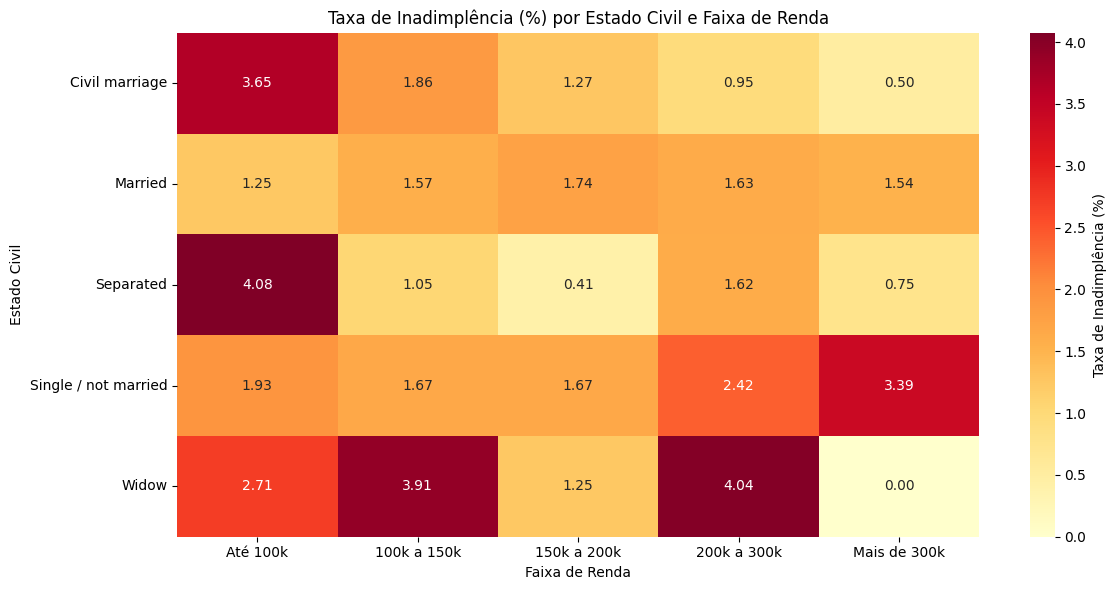

In [34]:
taxa_inadimplencia = df.groupby(['NAME_FAMILY_STATUS', 'FAIXA_RENDA'], observed=False)['MAU_PAGADOR'].mean().unstack() * 100

plt.figure(figsize=(12, 6))
sns.heatmap(taxa_inadimplencia, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Taxa de Inadimplência (%)'})
plt.title('Taxa de Inadimplência (%) por Estado Civil e Faixa de Renda')
plt.ylabel('Estado Civil')
plt.xlabel('Faixa de Renda')
plt.tight_layout()
plt.show()

**Avaliação**

Ao cruzar a "Faixa de Renda" com o "Estado Civil", identificamos comportamentos de risco bem específicos:

1. "Viúvos": apresentam taxas de inadimplência muito elevadas na faixa de renda mais baixa (Até 100k) e nas faixas intermediárias, chegando a atingir picos em comparação a outros grupos. No entanto, a taxa cai a zero na faixa de maior renda, indicando alta sensibilidade do risco desse grupo em relação ao orçamento disponível.

2. "Solteiros": mantêm uma taxa de inadimplência persistentemente alta (frequentemente acima de 2.5% a 3%) nas faixas de renda baixa e média-baixa. Isso sugere que a ausência de uma renda familiar compartilhada pode tornar este grupo mais vulnerável a imprevistos financeiros.

3. "Casados": apresentam o comportamento mais estável e seguro, com taxas de inadimplência historicamente baixas e controladas (geralmente entre 1.2% e 1.7%) independentemente da faixa de renda. A estabilidade de um orçamento compartilhado parece mitigar os riscos de crédito de forma eficaz.

**3. Presença de Carro/Imóvel vs. Escolaridade e Renda**

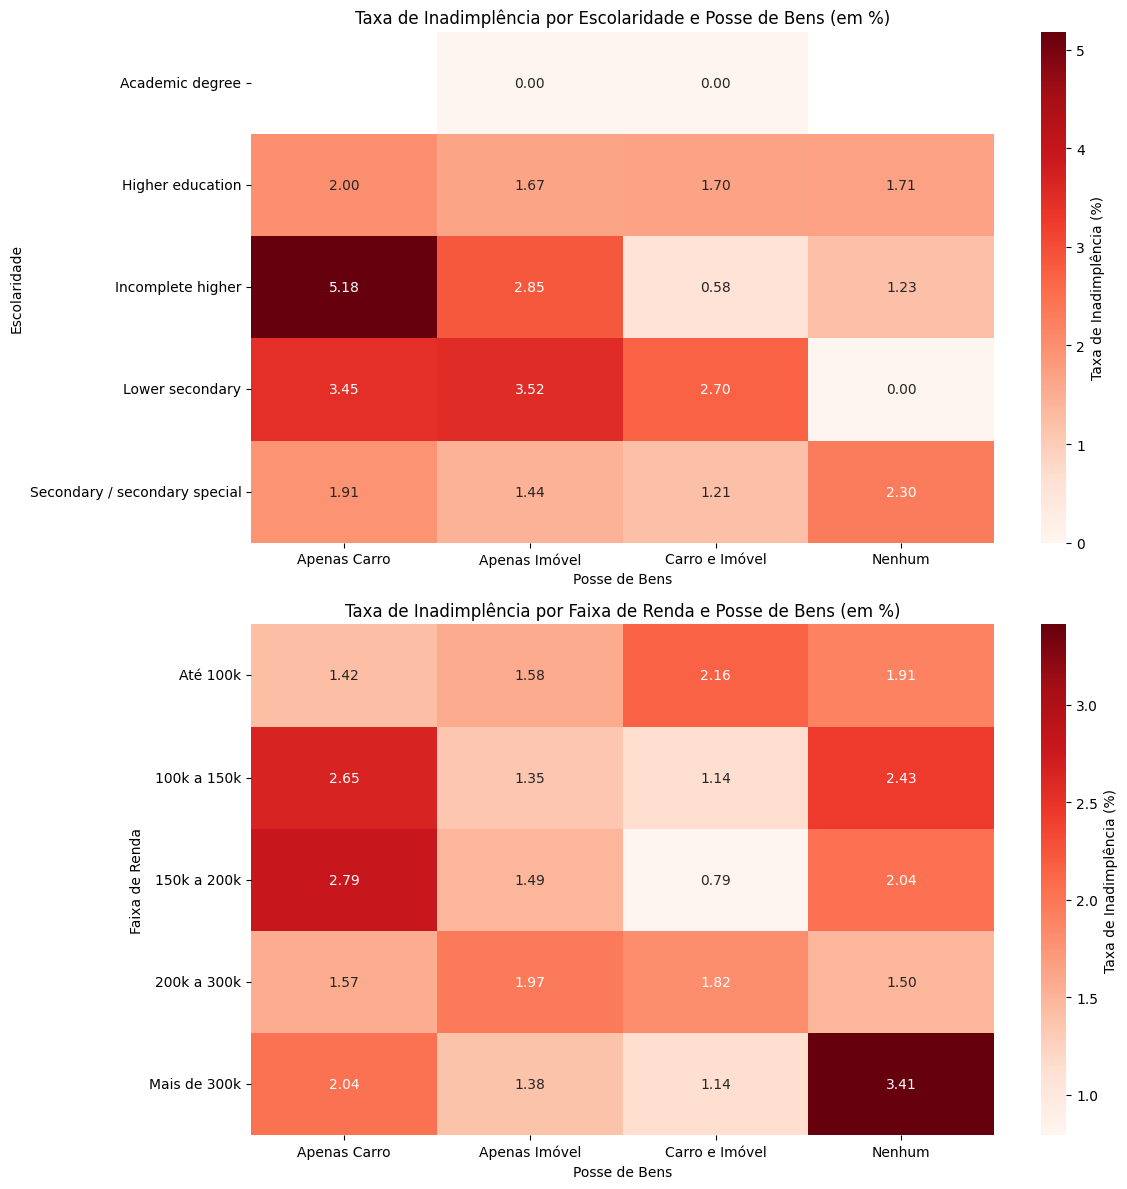

In [35]:
def classificar_bens(row):
    if row['FLAG_OWN_CAR'] == 'Y' and row['FLAG_OWN_REALTY'] == 'Y':
        return 'Carro e Imóvel'
    elif row['FLAG_OWN_CAR'] == 'Y':
        return 'Apenas Carro'
    elif row['FLAG_OWN_REALTY'] == 'Y':
        return 'Apenas Imóvel'
    else:
        return 'Nenhum'

df['POSSE_BENS'] = df.apply(classificar_bens, axis=1)

# 1. Taxa de inad por Posse de Bens e Escolaridade
taxa_bens_edu = df.groupby(['NAME_EDUCATION_TYPE', 'POSSE_BENS'], observed=False)['MAU_PAGADOR'].mean().unstack() * 100

# 2. Taxa de inad por Posse de Bens e Faixa de Renda
taxa_bens_renda = df.groupby(['FAIXA_RENDA', 'POSSE_BENS'], observed=False)['MAU_PAGADOR'].mean().unstack() * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.heatmap(taxa_bens_edu, annot=True, fmt=".2f", cmap="Reds", ax=axes[0], cbar_kws={'label': 'Taxa de Inadimplência (%)'})
axes[0].set_title('Taxa de Inadimplência por Escolaridade e Posse de Bens (em %)')
axes[0].set_ylabel('Escolaridade')
axes[0].set_xlabel('Posse de Bens')

sns.heatmap(taxa_bens_renda, annot=True, fmt=".2f", cmap="Reds", ax=axes[1], cbar_kws={'label': 'Taxa de Inadimplência (%)'})
axes[1].set_title('Taxa de Inadimplência por Faixa de Renda e Posse de Bens (em %)')
axes[1].set_ylabel('Faixa de Renda')
axes[1].set_xlabel('Posse de Bens')

plt.tight_layout()
plt.show()

**Avaliação**

Através dos gráficos acima, verificamos que:
- Clientes que não possuem nenhum bem (Nenhum) tendem a apresentar taxas de inadimplência mais acentuadas em determinadas faixas de renda e níveis de escolaridade.
- A posse combinada de "Carro" e "Imóvel" parece atuar como um forte indicador de estabilidade financeira, reduzindo sensivelmente a taxa de inadimplência na maior parte dos cruzamentos.